<a href="https://colab.research.google.com/github/prabh2012/Data-Analytics-Laboratory/blob/main/Practical4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape: (85, 13)

Columns:
 Index(['competitorname', 'chocolate', 'fruity', 'caramel', 'peanutyalmondy',
       'nougat', 'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
       'pricepercent', 'winpercent'],
      dtype='object')

Numeric Columns:
 Index(['chocolate', 'fruity', 'caramel', 'peanutyalmondy', 'nougat',
       'crispedricewafer', 'hard', 'bar', 'pluribus', 'sugarpercent',
       'pricepercent', 'winpercent'],
      dtype='object')
       chocolate     fruity    caramel  peanutyalmondy     nougat  \
count  85.000000  85.000000  85.000000       85.000000  85.000000   
mean    0.435294   0.447059   0.164706        0.164706   0.082353   
std     0.498738   0.500140   0.373116        0.373116   0.276533   
min     0.000000   0.000000   0.000000        0.000000   0.000000   
25%     0.000000   0.000000   0.000000        0.000000   0.000000   
50%     0.000000   0.000000   0.000000        0.000000   0.000000   
75%     1.000000   1.000000   0.000000        0.000000 

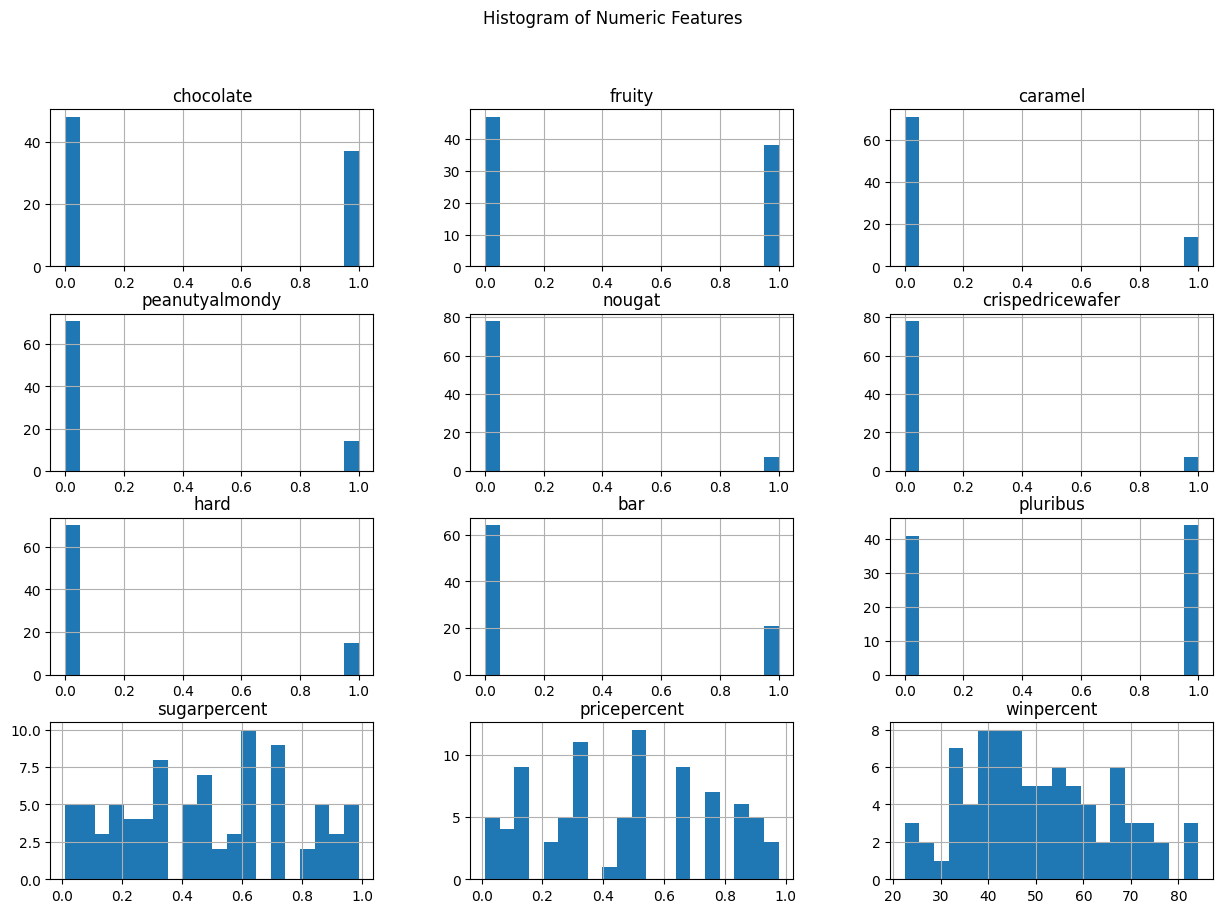

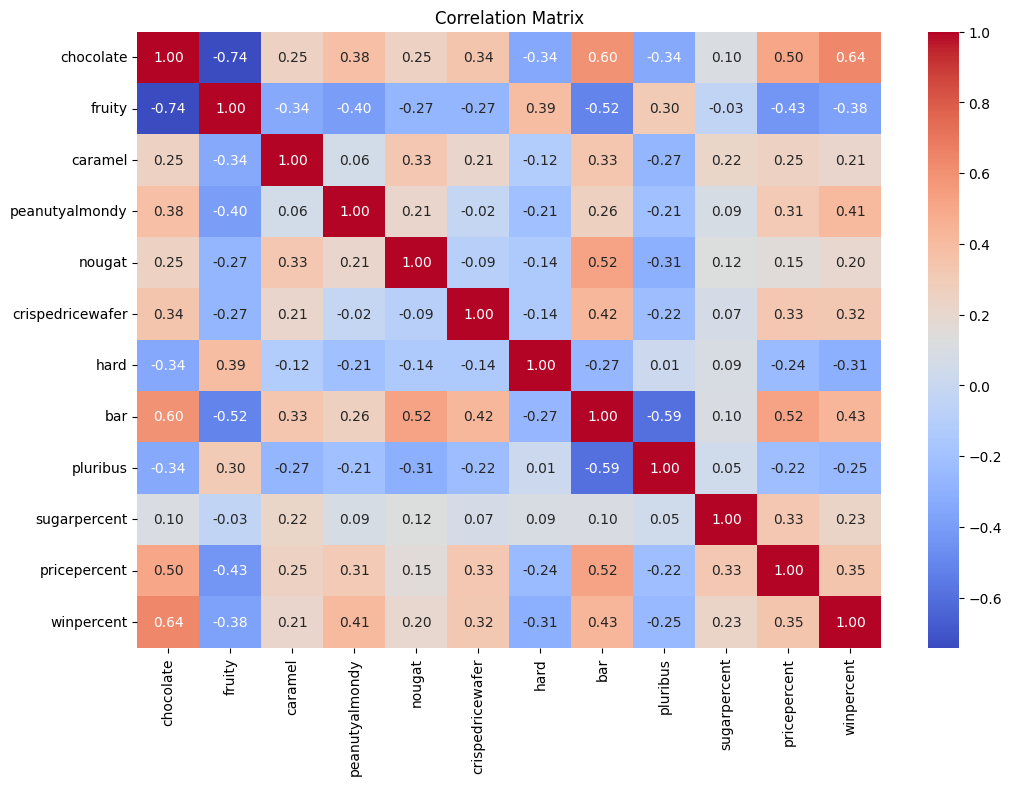

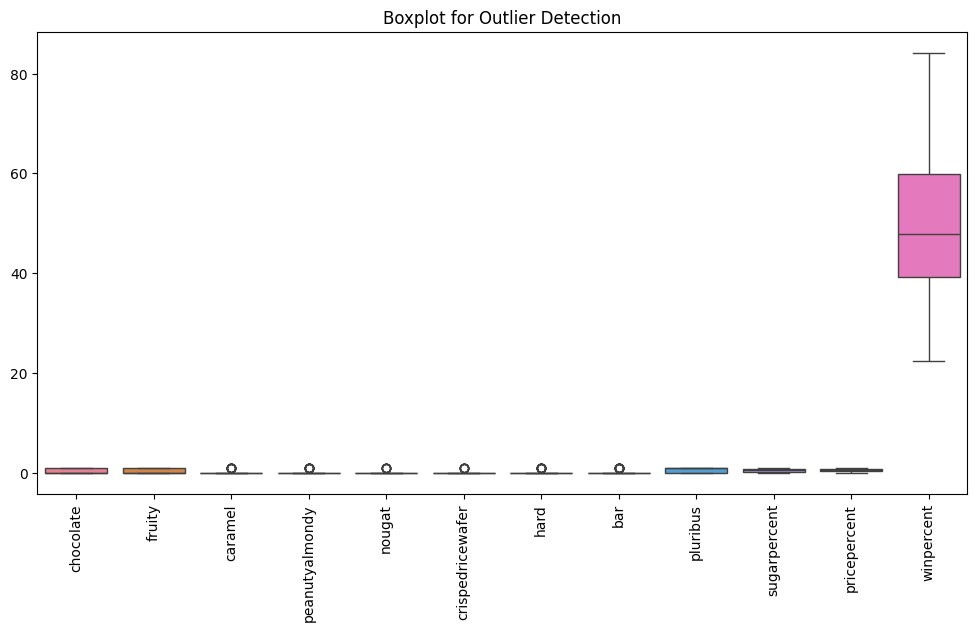

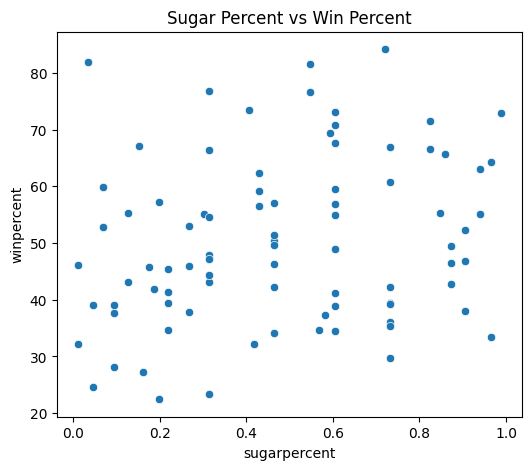


Model Evaluation:
MAE: 9.906697300617683
MSE: 160.982952385319
RMSE: 12.687905752539267
R2 Score: 0.19699888334669757


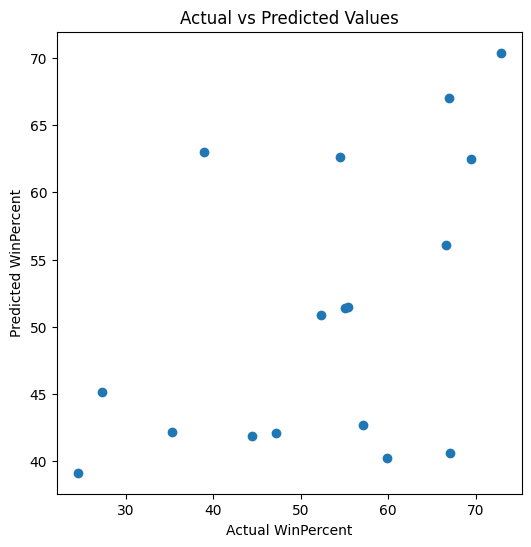

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load dataset
file_path = "/content/candy-data.csv"   # Change if running locally
df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:\n", df.columns)

# Select numeric columns only
numeric_df = df.select_dtypes(include=[np.number])

print("\nNumeric Columns:\n", numeric_df.columns)
print(numeric_df.describe())

# Histogram
numeric_df.hist(figsize=(15, 10), bins=20)
plt.suptitle("Histogram of Numeric Features")
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=numeric_df)
plt.xticks(rotation=90)
plt.title("Boxplot for Outlier Detection")
plt.show()

# Scatter plot (Sugar vs WinPercent)
plt.figure(figsize=(6, 5))
sns.scatterplot(x="sugarpercent", y="winpercent", data=numeric_df)
plt.title("Sugar Percent vs Win Percent")
plt.show()

# ------------------ MACHINE LEARNING ------------------

# Define target
target = "winpercent"

X = numeric_df.drop(columns=[target])
y = numeric_df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model training
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Actual vs Predicted plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual WinPercent")
plt.ylabel("Predicted WinPercent")
plt.title("Actual vs Predicted Values")
plt.show()